In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots 
import numpy as np

plt.style.use(["science","notebook", "grid"])

from funciones import joint_simulation, get_molecules

from ase.visualize import view
from ase.io import read, write
from ase.geometry.analysis import get_rdf # < ----- Dio muchos problemas
from rdfpy import rdf

# Completed simulation

Untill today

In [20]:
md = joint_simulation(folders=["./outputs_1","./outputs_2", "./outputs_3"])


Processing folder: ./outputs_1
Processing file: pw.out.27896 ---- 217 frames
Processing file: pw.out.27972 ---- 177 frames
Processing file: pw.out.28006 ---- 228 frames
Processing file: pw.out.28046 ---- 201 frames
Processing file: pw.out.28099 ---- 169 frames
Total frames on ./outputs_1 folder: 992

Processing folder: ./outputs_2
Processing file: pw.out.28895 ---- 182 frames
Processing file: pw.out.28984 ---- 183 frames
Processing file: pw.out.29046 ---- 169 frames
Processing file: pw.out.29139 ---- 178 frames
Processing file: pw.out.29374 ---- 186 frames
Processing file: pw.out.29624 ---- 185 frames
Processing file: pw.out.29799 ---- 195 frames
Processing file: pw.out.29937 ---- 196 frames
Processing file: pw.out.30033 ---- 200 frames
Processing file: pw.out.30117 ---- 209 frames
Total frames on ./outputs_2 folder: 2875

Processing folder: ./outputs_3
Processing file: pw.out.119 ---- 208 frames
Processing file: pw.out.120 ---- 200 frames
Processing file: pw.out.121 ---- 185 frames
P

In [21]:
energies = np.zeros(len(md))
temperatures = np.zeros(len(md))
for i in range(len(md)):
	energies[i] = md[i].get_potential_energy()
	temperatures[i] = md[i].info['temperature']

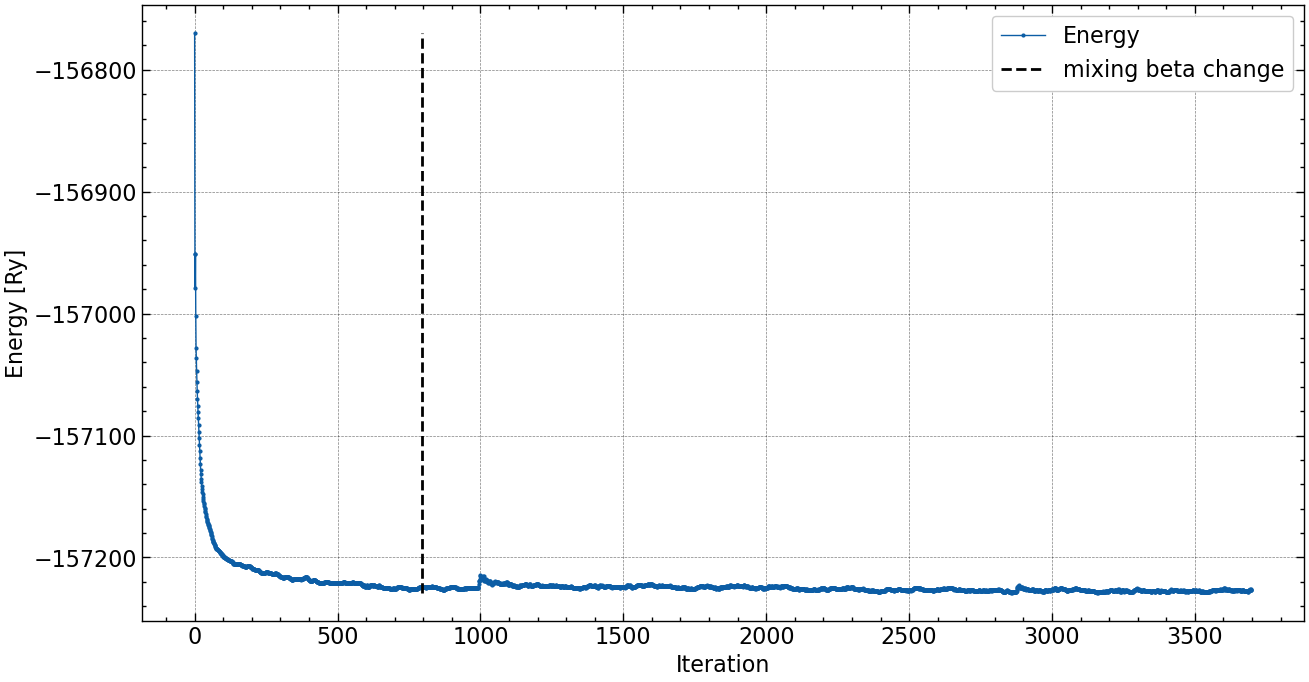

In [22]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms = 2, linewidth = 1, label = 'Energy')
ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia.png")

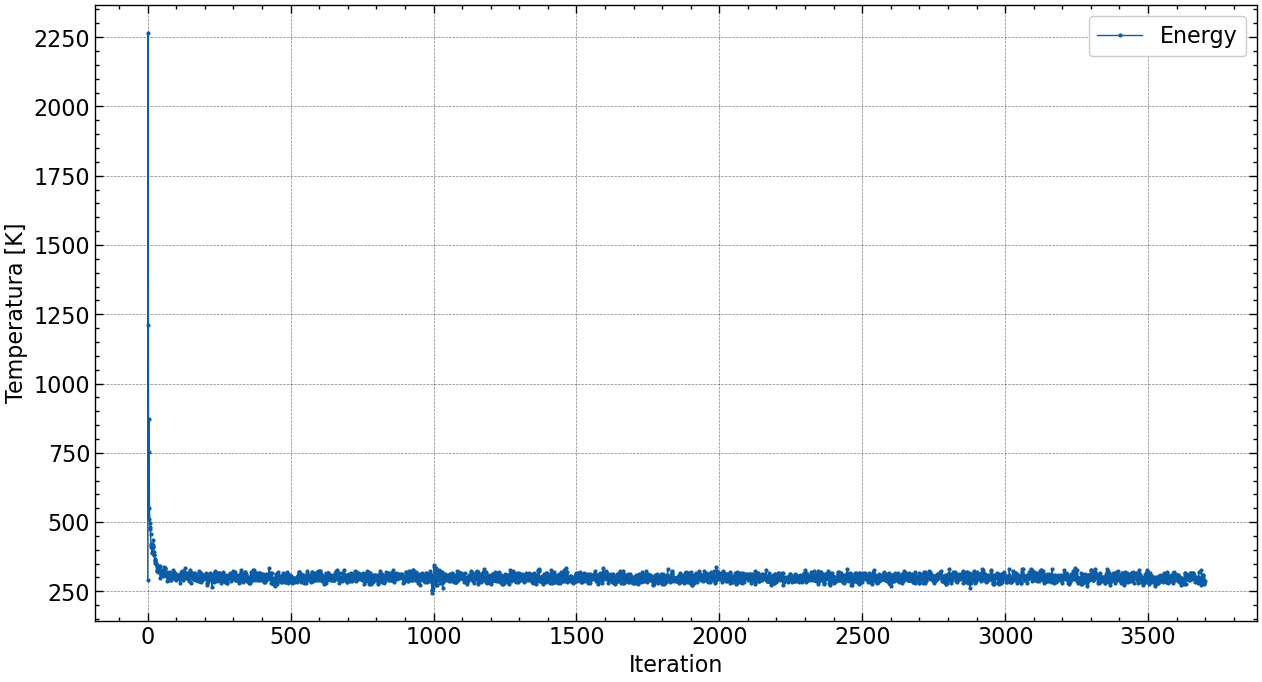

In [23]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(temperatures, 'o-', ms = 2, linewidth = 1, label = 'Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura.png")

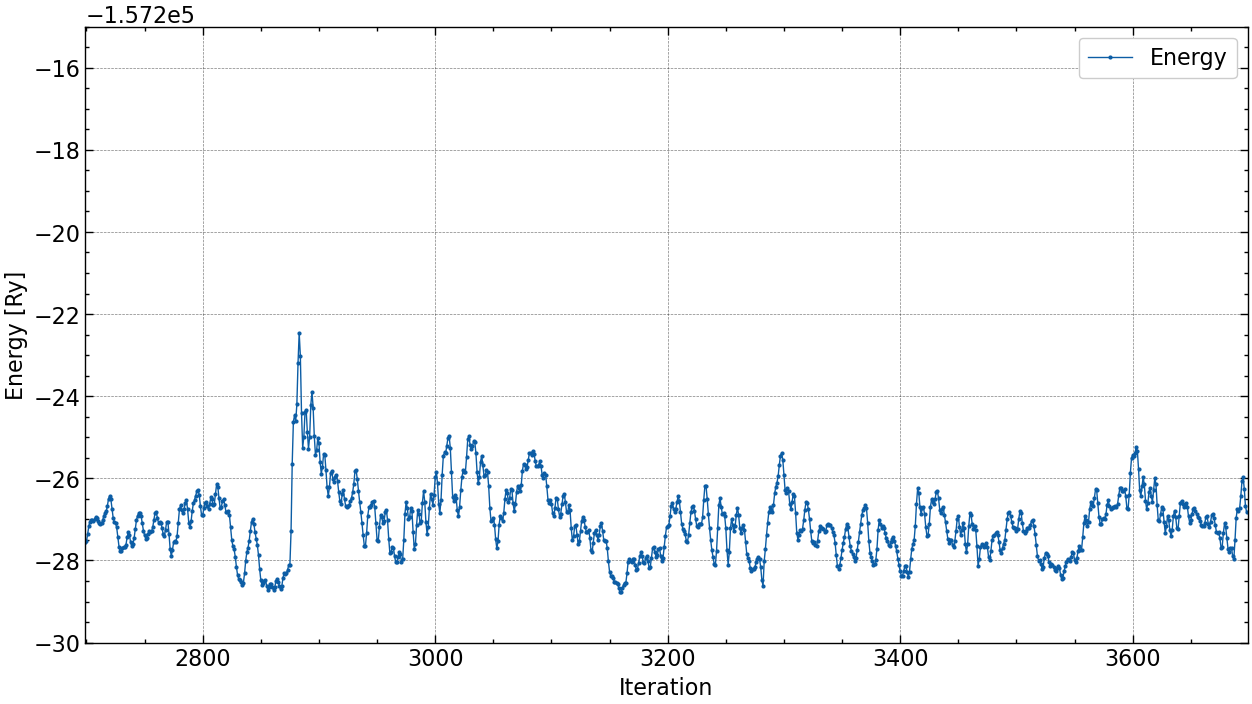

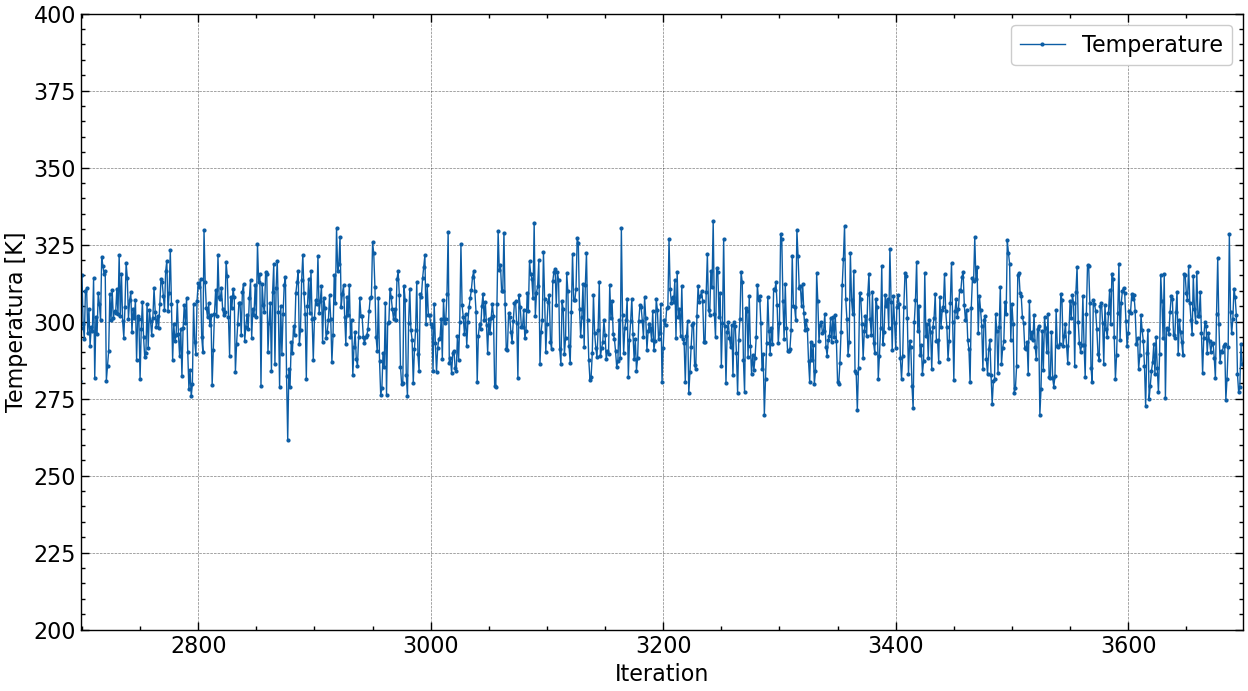

In [24]:
# === PRIMERA GRAFICA: Energía ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms=2, linewidth=1, label='Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies),label="mixing beta change", color='black', linestyles='--')

# ZOOM en las ultimas 1000 iteraciones
N = len(energies)
ax.set_xlim(max(0, N-1000), N)
ax.set_ylim(ymax=-157215, ymin= -157230)

ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia_zoom.png")


# === SEGUNDA GRAFICA: Temperatura ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(temperatures, 'o-', ms=2, linewidth=1, label='Temperature')

# ZOOM en las ultimas 1000 iteraciones
N2 = len(temperatures)
ax.set_xlim(max(0, N2-1000), N2)
ax.set_ylim(200,400)

ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura_zoom.png")


In [25]:
md[0].symbols.indices()['Al']

array([ 3,  7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51])

In [26]:
electrolyte = get_molecules(['molecules/alcl3_opt.xyz','molecules/1-Ethyl-3-methylimidazolium_chloride_opt.xyz'], 'inputs/pw_inicial.in')
len(electrolyte) # if it is 30, all is ok

30

In [27]:
electrolyte_idx = np.zeros(len(electrolyte), dtype=object)

for i in range(len(electrolyte)):
	electrolyte_idx[i] = np.zeros(len(electrolyte[i].atomos), dtype=int)
	print(f"Molecule {i}: {electrolyte[i]}")
	for j in range(len(electrolyte[i].atomos)):
		print(f"  Atom {j} - {electrolyte[i].atomos[j].simbolo}: {electrolyte[i].atomos[j].idx}")
		electrolyte_idx[i][j] = electrolyte[i].atomos[j].idx
electrolyte_idx_conca = np.concatenate(electrolyte_idx)

# indixes: 
# 0 - 12 : AlCl3
# 13 - 29 : EMImCl
# Check output

Molecule 0: <funciones.Molecula object at 0x7420b759b830>
  Atom 0 - Cl: 0
  Atom 1 - Cl: 1
  Atom 2 - Cl: 2
  Atom 3 - Al: 3
Molecule 1: <funciones.Molecula object at 0x7420b7598b30>
  Atom 0 - Cl: 4
  Atom 1 - Cl: 5
  Atom 2 - Cl: 6
  Atom 3 - Al: 7
Molecule 2: <funciones.Molecula object at 0x7420b7598110>
  Atom 0 - Cl: 8
  Atom 1 - Cl: 9
  Atom 2 - Cl: 10
  Atom 3 - Al: 11
Molecule 3: <funciones.Molecula object at 0x7420b759a750>
  Atom 0 - Cl: 12
  Atom 1 - Cl: 13
  Atom 2 - Cl: 14
  Atom 3 - Al: 15
Molecule 4: <funciones.Molecula object at 0x7420b759a1b0>
  Atom 0 - Cl: 16
  Atom 1 - Cl: 17
  Atom 2 - Cl: 18
  Atom 3 - Al: 19
Molecule 5: <funciones.Molecula object at 0x7420b759b4d0>
  Atom 0 - Cl: 20
  Atom 1 - Cl: 21
  Atom 2 - Cl: 22
  Atom 3 - Al: 23
Molecule 6: <funciones.Molecula object at 0x7420b759b7d0>
  Atom 0 - Cl: 24
  Atom 1 - Cl: 25
  Atom 2 - Cl: 26
  Atom 3 - Al: 27
Molecule 7: <funciones.Molecula object at 0x7420b759b8f0>
  Atom 0 - Cl: 28
  Atom 1 - Cl: 29
  Atom

In [28]:
nanoscroll_idx = np.arange(electrolyte_idx_conca[-1]+1,len(md[0]),1, dtype=int)
#nanoscroll_idx

In [29]:
carbons_electrolyte = np.concatenate([mol_idx[2:8] for mol_idx in electrolyte_idx[13:]
])
#carbons_electrolyte

In [30]:
all_c = np.concatenate([carbons_electrolyte,nanoscroll_idx])

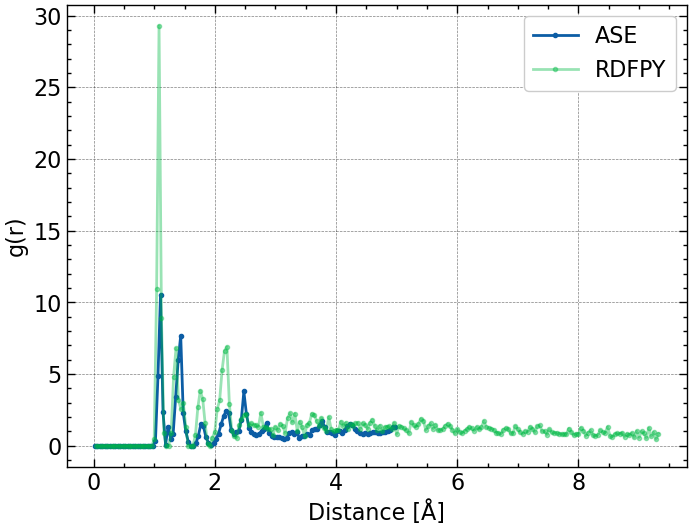

In [31]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
rdf_ase, r_ase = get_rdf(md[-1],5.0,120)

rdf_rdfpy, r_rdfpy = rdf(md[-1].positions, dr=0.04)

ax.plot(r_ase, rdf_ase,'o-',ms = 3,  label='ASE')
ax.plot(r_rdfpy, rdf_rdfpy,'o-', ms = 3, label='RDFPY', alpha=0.4)
ax.set_xlabel("Distance [Å]")
ax.set_ylabel("g(r)")
ax.legend()




Trabajar con ASE estaba dando varios problemas para poder calcular la RDF, principalmente no era posible seleccionar elementos en especifico para que se realizara el calculo.

In [ ]:
# Seleccionando todos los carbonos del nanoscroll y los carbonos del electrolito (EmimCl)
for i in range(0,len(md),25):

	fig, ax = plt.subplots(1,1, figsize=(8,6))

	gr, r = rdf(md[i][all_c].positions, dr= 0.05)

	ax.plot(r, gr,'o-',ms = 2, linewidth = 1, label = f'RDFPY - frame: {i}')


	ax.set_title("RDF C - nanoscroll C-electrolyte")
	ax.set_ylim(ymax=35)
	ax.set_xlim(xmax=10)
	ax.set_xlabel("Distance [Å]")
	ax.set_ylabel("g(r)")
	ax.legend()
	fig.savefig(f'./rdf/rdf_CC{i}.png')
	plt.close(fig)

/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hernan-barquero/anaconda3/envs/general/lib/python3.13/site-packages/rdfpy/rdfpy.py:27: RuntimeWarning: invalid value encountered in scalar divide
  g_r_partial[r_idx] /= n_valid*shell_vol*rho
/home/hern